In [1]:
import pandas as pd
df = pd.read_csv("Mall_customers.csv")

In [2]:
df.shape

(200, 5)

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("Gender values:")
print(df["Gender"].value_counts())

Gender values:
Gender
Female    112
Male       88
Name: count, dtype: int64


In [10]:
'''
I will not use CustomerID because it is just an identifier. For this project, i'll also leave Gender out of the K-Means features so the clusters are based directly on purchasing-related numerical behavior plus age.
'''

"\nI will not use CustomerID because it is just an identifier. For this project, i'll also leave Gender out of the K-Means features so the clusters are based directly on purchasing-related numerical behavior plus age.\n"

In [11]:
# Select features for clustering
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [12]:
X.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [14]:
X_scaled.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,7.284319e-01,6.656748e-01,8.851316e-01
max,2.235532e+00,2.917671e+00,1.894492e+00


Inertia values:
K=2: 389.39
K=3: 295.21
K=4: 205.23
K=5: 168.25
K=6: 133.87
K=7: 117.01
K=8: 103.87
K=9: 93.09
K=10: 82.39


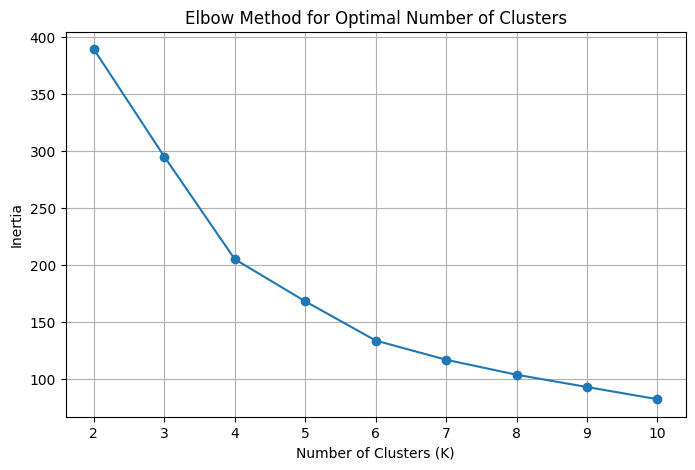

In [15]:
#Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(K, inertia):
    print(f"K={k}: {value:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K)
plt.grid(True)
plt.show()

In [16]:
# Applying K-Means with optimal K
optimal_k = 6

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Adding cluster labels to original dataset
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


In [17]:
print("Customers in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Customers in each cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


In [18]:
cluster_summary = df.groupby("Cluster")[features].mean().round(2)

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        56.33               54.27                   49.07
1        26.79               57.10                   48.13
2        41.94               88.94                   16.97
3        32.69               86.54                   82.13
4        25.00               25.26                   77.61
5        45.52               26.29                   19.38


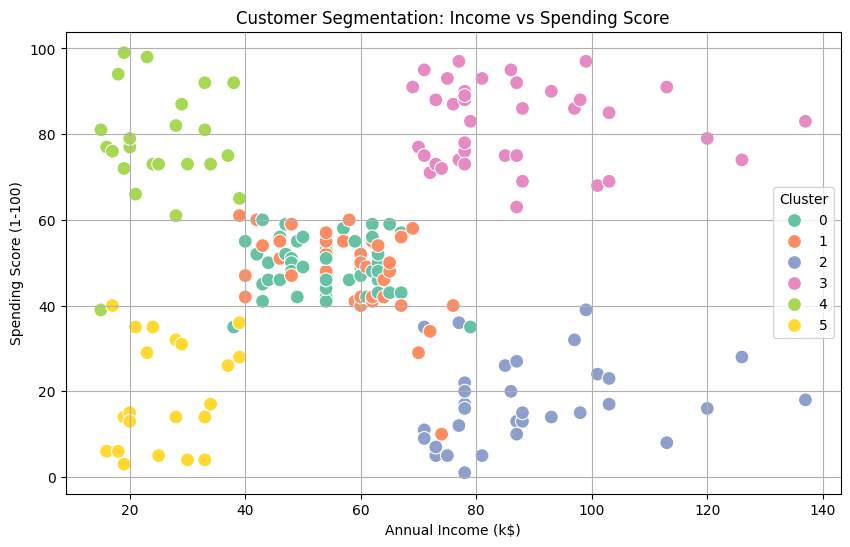

In [21]:
# 2D Visualization

import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("Customer Segmentation: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

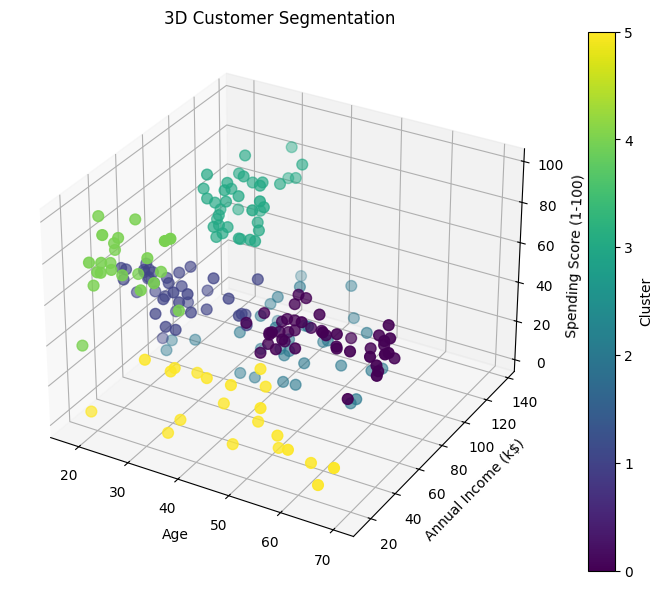

In [22]:
# 3D Customer Segmentation Visualization

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Age"],
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

ax.set_title("3D Customer Segmentation")
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")

plt.colorbar(scatter, label="Cluster")
plt.show()

In [23]:
#Saving clustered data

df.to_csv("Customer_Segmentation_Clusters.csv", index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


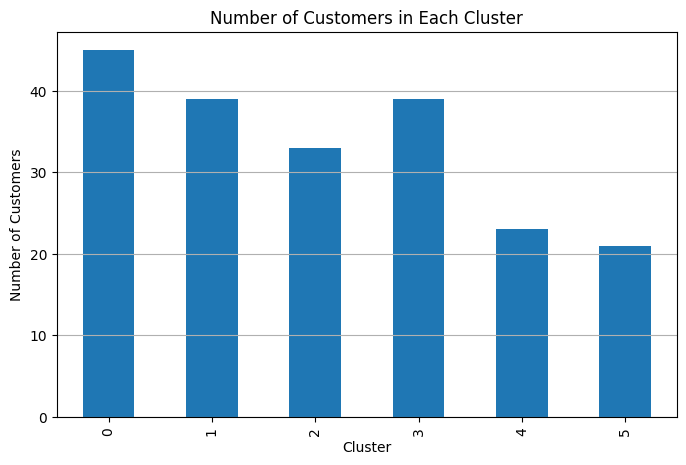

In [25]:
#Creating cluster size chart
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y")
plt.show()

In [26]:
plt.savefig("cluster_sizes.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
print("===== Customer Segmentation Summary =====")

print("Dataset Size:", len(df))
print("Features Used:", features)

print("Optimal Clusters:", optimal_k)

print("\nCustomers per Cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster Profiles:")
print(cluster_summary)

===== Customer Segmentation Summary =====
Dataset Size: 200
Features Used: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Optimal Clusters: 6

Customers per Cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

Cluster Profiles:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        56.33               54.27                   49.07
1        26.79               57.10                   48.13
2        41.94               88.94                   16.97
3        32.69               86.54                   82.13
4        25.00               25.26                   77.61
5        45.52               26.29                   19.38
